<a href="https://colab.research.google.com/github/Halgratir/DataAnalytics/blob/Maritime-Class-Excercise/PandasExcercise_Maritime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Load the dataframe
*   Set the index to the base_date_time. Your index should be a DateTimeIndex
*   Clean the data: we don't want any row where the sog is null
*   First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?
*   Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:
**a) **Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)
** b)**
** c)** Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.
 **c)** Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain

*   Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

df = pd.read_csv(
    url,
    compression="zstd",
    parse_dates=["base_date_time"],
    low_memory=False
)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5929631 entries, 0 to 5929630
Data columns (total 17 columns):
 #   Column          Dtype         
---  ------          -----         
 0   mmsi            int64         
 1   base_date_time  datetime64[ns]
 2   longitude       float64       
 3   latitude        float64       
 4   sog             float64       
 5   cog             float64       
 6   heading         float64       
 7   vessel_name     object        
 8   imo             object        
 9   call_sign       object        
 10  vessel_type     float64       
 11  status          float64       
 12  length          float64       
 13  width           float64       
 14  draft           float64       
 15  cargo           float64       
 16  transceiver     object        
dtypes: datetime64[ns](1), float64(11), int64(1), object(4)
memory usage: 769.1+ MB


In [ ]:
print(df.columns)

Index(['mmsi', 'base_date_time', 'longitude', 'latitude', 'sog', 'cog',
       'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status',
       'length', 'width', 'draft', 'cargo', 'transceiver'],
      dtype='object')


In [9]:
df['base_date_time'] = pd.to_datetime(df['base_date_time'])
df.set_index('base_date_time', inplace=True)

In [11]:
df = df.dropna(subset=['sog'])

Let's see if we can plot a line graph. First Analysis


In [14]:
#resample by hour and count unique MMSI
hourly_vessels = df.resample('h')['mmsi'].nunique()

note: keep in mind python is case sensitive "oops" 😂

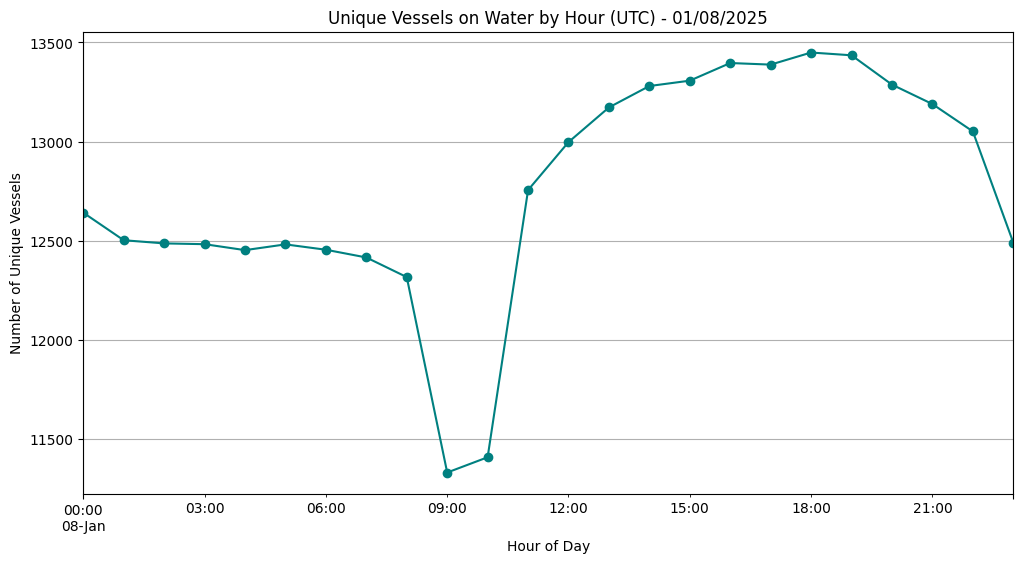

In [15]:
#plotting the results
plt.figure(figsize=(12, 6))
hourly_vessels.plot(kind='line', marker='o', color='teal')
plt.title('Unique Vessels on Water by Hour (UTC) - 01/08/2025')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Unique Vessels')
plt.grid(True)
plt.show()

In [18]:
#find max and min
peak_hour = hourly_vessels.idxmax().hour
low_hour = hourly_vessels.idxmin().hour
print(f"most boats out: {peak_hour}: 00 UTC")
print(f"least boats out: {low_hour}00 UTC")

most boats out: 18: 00 UTC
least boats out: 900 UTC


Generally, maritime activity fluctuates based on global shipping lanes and port operations. Least hours is late night/early morning hours across the US coastal time zones.

Second Analysis

In [19]:
#filter for te henry hudson
mmsi_hudson = 366651000
hudson_df = df[df['mmsi'] == mmsi_hudson].copy()

In [20]:
#sort index to ensure time continuity
hudson_df = hudson_df.sort_index()

In [21]:
#calculate acceleration (difference in sog)
hudson_df['acceleration'] = hudson_df['sog'].diff()

In [22]:
#Create a duration column
hudson_df['duration'] = hudson_df.index.to_series().diff()